

# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Brain Tumor Detection</p>




# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Importing Modules</p>

In [1]:
import seaborn as sns
import numpy as np 
import pandas as pd 
import cv2 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf 
from tensorflow.keras.models import Model , Sequential
from tensorflow.keras.layers import Dense,Conv2D, BatchNormalization , Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.utils import plot_model
from sklearn.utils.class_weight import compute_class_weight 

from tensorflow.keras.applications import  ResNet50V2 
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense

import os 
import glob  
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split 
import warnings
warnings.filterwarnings("ignore")



/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"




# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Preparing Data</p>

In [2]:
os.makedirs('/kaggle/working/Data/')

In [3]:

from tensorflow.keras.preprocessing.image import img_to_array ,load_img  

data_path= "/kaggle/input/mri-images/Data/" 
working_directory = '/kaggle/working/Data/' 
img_size= 300

df=pd.DataFrame({'path': [], 'picture_name':[] , 'label': [] , 'aug_type':[] }) 
df = df.set_index('path')

def images_in_folder(folder , floderlabel): 
    for picture_name in os.listdir(folder):  
        image = load_img(folder+picture_name, target_size=(224, 224))
        image = img_to_array(image) 
        imagePath = working_directory + picture_name
        cv2.imwrite(imagePath, image) 
        df.loc[imagePath]= [picture_name , floderlabel , 'org'] #Origional images


images_in_folder(data_path+'glioma_tumor/' , 'glioma_tumor')
images_in_folder(data_path+'meningioma_tumor/' , 'meningioma_tumor')
images_in_folder(data_path+'pituitary_tumor/' , 'pituitary_tumor')
images_in_folder(data_path+'normal/' , 'normal')
  

In [4]:
df

,picture_name,label,aug_type
path,,,
/kaggle/working/Data/G_622.jpg,G_622.jpg,glioma_tumor,org
/kaggle/working/Data/G_774.jpg,G_774.jpg,glioma_tumor,org
/kaggle/working/Data/G_680.jpg,G_680.jpg,glioma_tumor,org
/kaggle/working/Data/G_203.jpg,G_203.jpg,glioma_tumor,org
/kaggle/working/Data/G_9.jpg,G_9.jpg,glioma_tumor,org
...,...,...,...
/kaggle/working/Data/N_30.jpg,N_30.jpg,normal,org
/kaggle/working/Data/N_207.jpg,N_207.jpg,normal,org
/kaggle/working/Data/N_221.jpg,N_221.jpg,normal,org


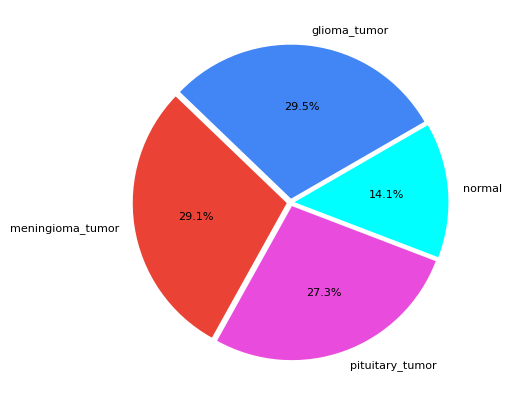

In [5]:
plt.figure(figsize=(5,5))
colors = ['#4285f4','#ea4335',"#e94cdc","#00FFFF"]
plt.rcParams.update({'font.size': 8})
df.label.value_counts()
plt.pie(df.label.value_counts(),
       labels= df.label.unique(),
       colors=colors, autopct='%.1f%%', explode=(0.025,0.025,0.025,0.025),
       startangle=30);

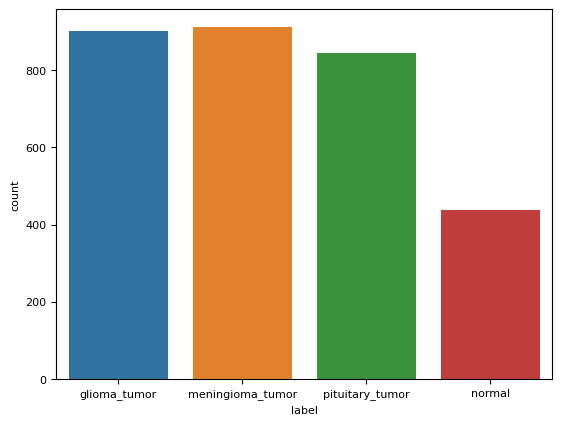

In [6]:
sns.countplot(df , x='label');



# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Some Visualizations</p>

In [7]:
labels=np.unique(df.label) 

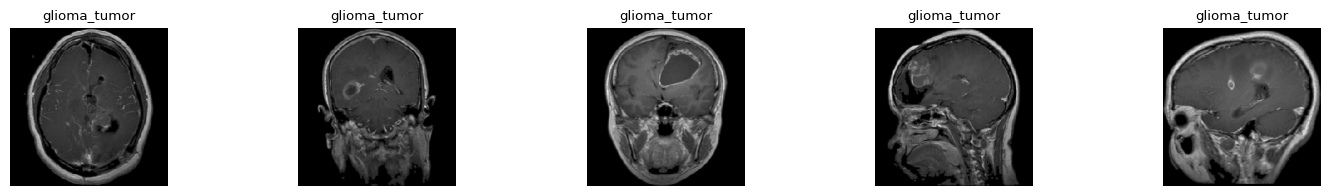

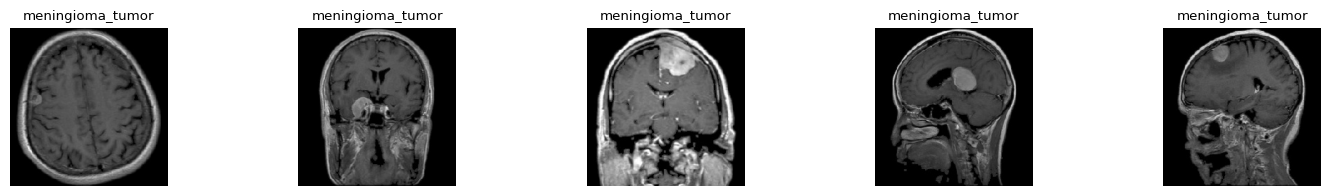

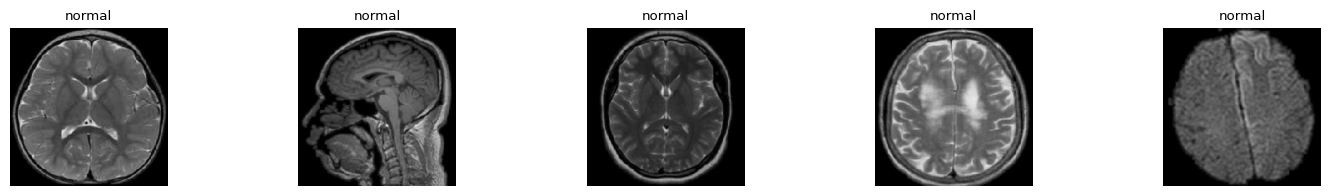

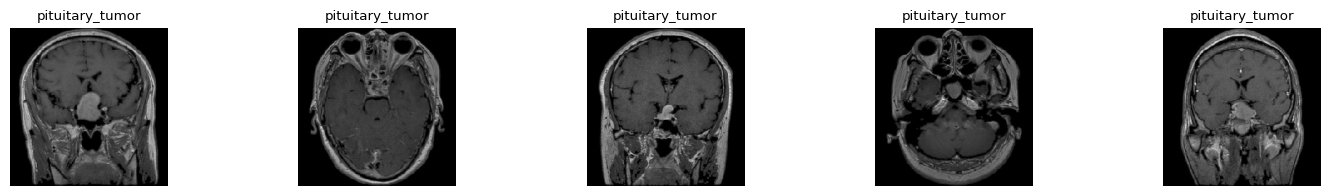

In [8]:
for lbl in labels:
        typ = df.loc[df.label == lbl]
        fig, ax=plt.subplots(1,5 , figsize= (15,2))
        for i,row in enumerate(typ.head(5).iterrows()):   
                ax[i].imshow(cv2.imread(row[0]));
                ax[i].set_title(row[1].label)
                ax[i].axis('off')
        plt.tight_layout() 




# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Incrementing The Data</p>

<h4>Blur filter</h4>

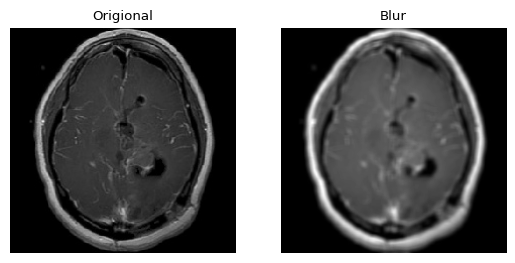

In [9]:
def apply_blur(path,  plot = False, save =False , save_path = working_directory ): 
    img = cv2.imread(path ) 
    filename = os.path.basename(path) 
    blur_image = cv2.blur(img, (5, 5)) 
    blur_image = cv2.cvtColor(blur_image, cv2.COLOR_RGB2GRAY)  
    if plot==True:
        _,ax = plt.subplots(1,2)
        ax[0].imshow(img, cmap='jet') 
        ax[1].imshow(blur_image, cmap='gray') 
        ax[0].set_title('Origional')
        ax[1].set_title('Blur')
        ax[0].axis('off')
        ax[1].axis('off')
        plt.show()
    if save ==True: 
        blr_path = save_path + 'blr_'+ filename
        cv2.imwrite(blr_path , blur_image  )
        df.loc[blr_path] = df.loc[path]
        df.loc[blr_path , 'aug_type'] = 'blr'
        #print(blr_path)
    return(blur_image)

#==============================================

path =df.index[0]
_ = apply_blur(path, plot = True ,save =False)

<h4>Clahe filter</h4>

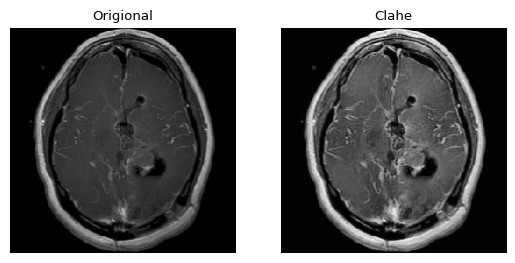

In [10]:
def apply_clahe(path , plot = False,  save =False , save_path = working_directory ): 
    img = cv2.imread(path)   
    filename = os.path.basename(path)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_gray_clahe = clahe.apply(cv2.split(lab)[0])   
    if plot==True:
        _,ax = plt.subplots(1,2)
        ax[0].imshow(img) 
        ax[1].imshow(image_gray_clahe , cmap='gray') 
        ax[0].set_title('Origional')
        ax[1].set_title('Clahe' )
        ax[0].axis('off')
        ax[1].axis('off')
        plt.show()    
    if save == True:
        cla_path = save_path + 'cla_'+ filename
        cv2.imwrite( cla_path, image_gray_clahe)
        df.loc[cla_path] = df.loc[path]
        df.loc[cla_path , 'aug_type'] = 'cla'
        #print(cla_path)
    return(image_gray_clahe)

#====================================
path =df.index[0]
_ = apply_clahe(path,   plot = True , save= False)


<h4>Sobel filter</h4>

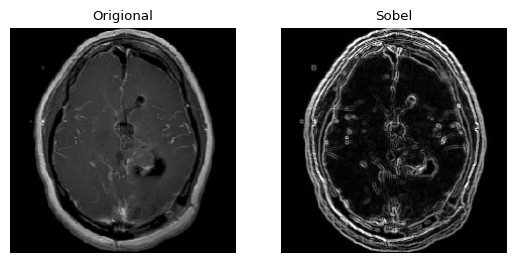

In [11]:
def apply_sobel(path, plot = False,  save =False , save_path = working_directory ): 
    img = cv2.imread(path)
    filename = os.path.basename(path)    
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3) 
    sobel_x = cv2.convertScaleAbs(sobel_x)
    sobel_y = cv2.convertScaleAbs(sobel_y)
    sobel = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)
    if plot==True:
        _,ax = plt.subplots(1,2)
        ax[0].imshow(img) 
        ax[1].imshow(sobel  , cmap='gray') 
        ax[0].set_title('Origional')
        ax[1].set_title('Sobel')
        ax[0].axis('off')
        ax[1].axis('off')
        plt.show()    
    if save == True:
        sbl_path = save_path + 'sbl_'+ filename
        cv2.imwrite(sbl_path, sobel)
        df.loc[sbl_path] = df.loc[path]
        df.loc[sbl_path , 'aug_type'] = 'sbl'
        #print(la_path)
    return(sobel)

#====================================
path =df.index[0]
_ = apply_sobel(path,  plot = True , save = False)

In [12]:
for p in df.index:
    apply_blur(p,  plot = False  , save=True)
    apply_clahe(p,  plot = False  , save=True)
    #apply_sobel(p,  plot = False  , save=True)

In [13]:
data = df.reset_index()
np.unique(data.aug_type)

array(['blr', 'cla', 'org'], dtype=object)


# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Separating The Test Set</p>

Separate tiny part of real images for Test set "testX". The rest images called "exceptTest" will be used for validation and train.

In [14]:
_ ,testX  = train_test_split(data[data.aug_type == 'org'], test_size=0.002, random_state=14) 

exceptTest = data[~data.isin(testX)].dropna()
len(testX)

7



# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Building The Model</p>

In [15]:

(trainX, validX) = train_test_split(exceptTest, test_size=0.20, random_state=14)
testX.head()

,path,picture_name,label,aug_type
1189,/kaggle/working/Data/M_741.jpg,M_741.jpg,meningioma_tumor,org
3009,/kaggle/working/Data/N_159.jpg,N_159.jpg,normal,org
2410,/kaggle/working/Data/P_44.jpg,P_44.jpg,pituitary_tumor,org
1190,/kaggle/working/Data/M_617.jpg,M_617.jpg,meningioma_tumor,org
870,/kaggle/working/Data/G_477.jpg,G_477.jpg,glioma_tumor,org


In [16]:
BS=64
target_size = (224 , 224)


datagen = ImageDataGenerator(
    rescale=1./255,
    #rotation_range=30,
    #width_shift_range=0.1,
    #height_shift_range=0.1,
    #zoom_range=0.2,
    #horizontal_flip=True
)

train_generator = datagen.flow_from_dataframe(
    target_size = target_size ,
    dataframe = trainX,
    x_col='path',
    y_col='label', 
    batch_size=BS,
    class_mode="categorical"
    )

valid_generator = datagen.flow_from_dataframe(
    target_size = target_size,
    dataframe=validX,
    x_col='path',
    y_col='label', 
    batch_size=BS,
    class_mode='categorical'
    )

test_datagenerator = ImageDataGenerator(rescale=1./255)

test_generator = test_datagenerator.flow_from_dataframe(
    target_size = target_size,
    dataframe=testX,
    batch_size=BS,
    x_col='path',
    y_col='label', 
    class_mode='categorical',
    shuffle=False
    )

Found 7424 validated image filenames belonging to 4 classes.
Found 1857 validated image filenames belonging to 4 classes.
Found 7 validated image filenames belonging to 4 classes.


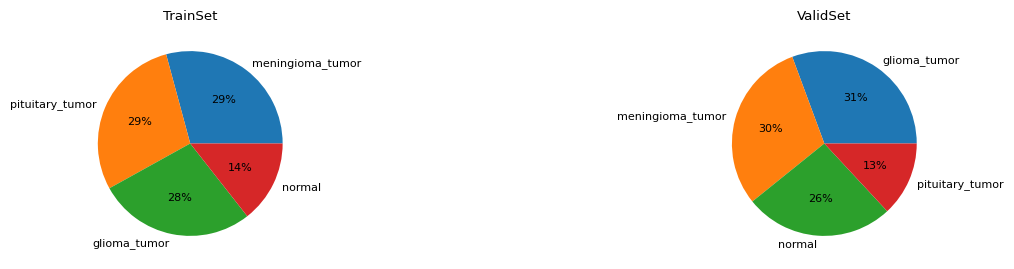

In [17]:
fig , ax= plt.subplots(1,2 , figsize=(15,3))
#sns.countplot(trainX , x='label', ax=ax[0] );  
ax[0].pie(trainX.label.value_counts(), labels= trainX.label.unique(),    autopct='%.0f%%')
ax[0].set_title('TrainSet') 
#sns.countplot(testX , x='label', ax=ax[1]) 
ax[1].pie(validX.label.value_counts(), labels= validX.label.unique(),    autopct='%.0f%%')
ax[1].set_title('ValidSet') 
plt.show()

In [18]:
gen_dict = train_generator.class_indices
classes = list(gen_dict.keys())
images , labels = next(train_generator)
img_shape = (target_size[0] , target_size[1] , 3)
num_class = len(classes)

weights = compute_class_weight(class_weight='balanced',
                               classes=np.unique(train_generator.classes),
                               y=train_generator.classes)
class_weights = dict(zip(np.unique(train_generator.classes), weights))
class_weights

{0: 0.8664799253034547,
 1: 0.8560885608856088,
 2: 1.7345794392523364,
 3: 0.9080234833659491}

In [19]:
import tensorflow
import keras

base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=img_shape) 
base_model.trainable = False
model = tensorflow.keras.models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dropout(0.5),  
    Dense(num_class , activation = 'softmax')
])

#optimizer
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'categorical_crossentropy', 
              metrics = ['accuracy',
                         tensorflow.keras.metrics.Precision() ,
                         tensorflow.keras.metrics.Recall()]
             ) 

 
model.summary()
    

94668760/94668760 [==============================] - 3s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50v2 (Functional)     (None, 7, 7, 2048)        23564800  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 1024)              2098176   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 4)                 4100      
                                                                 
Total params: 25667076 (97.91 MB)
Trainable params: 21022

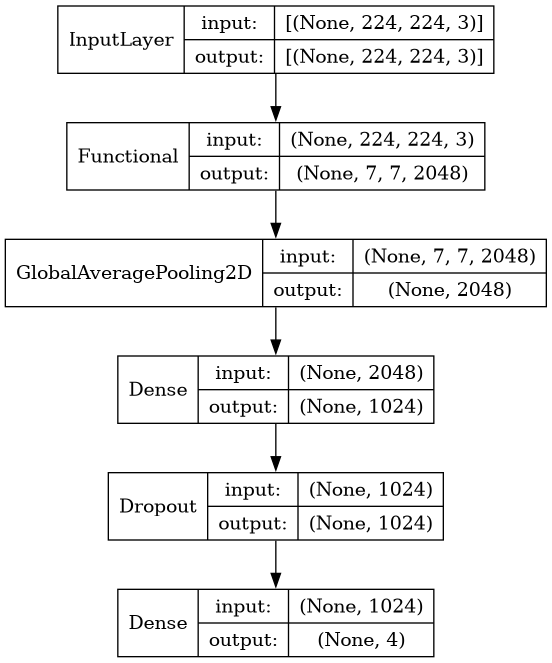

In [20]:
#plot_model
plot_model(model, show_shapes=True, show_layer_names=False)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(monitor = "val_loss",  patience = 30, mode = "min")
checkp = ModelCheckpoint(filepath = '/kaggle/working/opt1Channelmodel.h5',
                         monitor = "val_recall",
                         mode = 'max', 
                         save_best_only = True, 
                         save_format='keras')
  
history = model.fit(train_generator,
                    validation_data= valid_generator,
                    steps_per_epoch=train_generator.samples // BS,
                    validation_steps=valid_generator.samples // BS,
                    callbacks=[es, checkp],
                    class_weight=class_weights,
                    epochs=200)

model.save('/kaggle/working/last_model.keras')

Epoch 1/200
116/116 [==============================] - 27s 179ms/step - loss: 0.8692 - accuracy: 0.6401 - precision: 0.6973 - recall: 0.5678 - val_loss: 0.5752 - val_accuracy: 0.7915 - val_precision: 0.8360 - val_recall: 0.7387
Epoch 2/200
116/116 [==============================] - 20s 172ms/step - loss: 0.5110 - accuracy: 0.7893 - precision: 0.8263 - recall: 0.7496 - val_loss: 0.4468 - val_accuracy: 0.8373 - val_precision: 0.8663 - val_recall: 0.8098
Epoch 3/200
116/116 [==============================] - 20s 173ms/step - loss: 0.4069 - accuracy: 0.8357 - precision: 0.8654 - recall: 0.8025 - val_loss: 0.4077 - val_accuracy: 0.8464 - val_precision: 0.8777 - val_recall: 0.8233
Epoch 4/200
116/116 [==============================] - 20s 171ms/step - loss: 0.3386 - accuracy: 0.8695 - precision: 0.8953 - recall: 0.8431 - val_loss: 0.3626 - val_accuracy: 0.8728 - val_precision: 0.8974 - val_recall: 0.8438
Epoch 5/200
116/116 [==============================] - 20s 170ms/step - loss: 0.2894 - a



## <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Validation</p>
 

In [22]:
criterions = sorted(history.history.keys())
criterions

['accuracy',
 'loss',
 'precision',
 'recall',
 'val_accuracy',
 'val_loss',
 'val_precision',
 'val_recall']

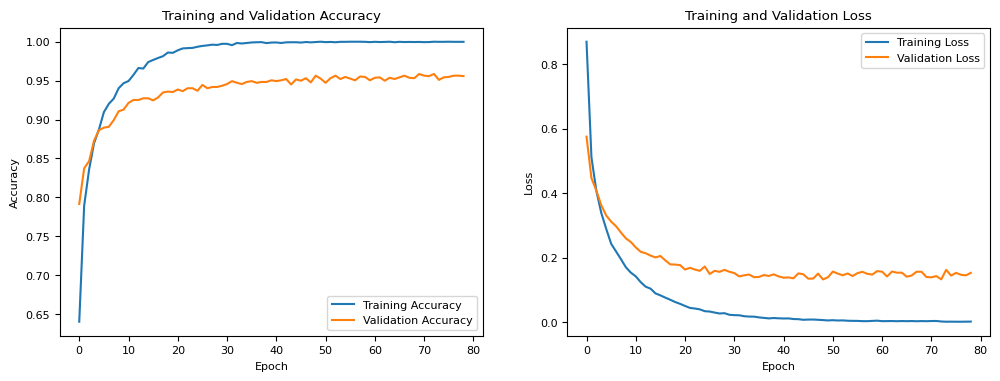

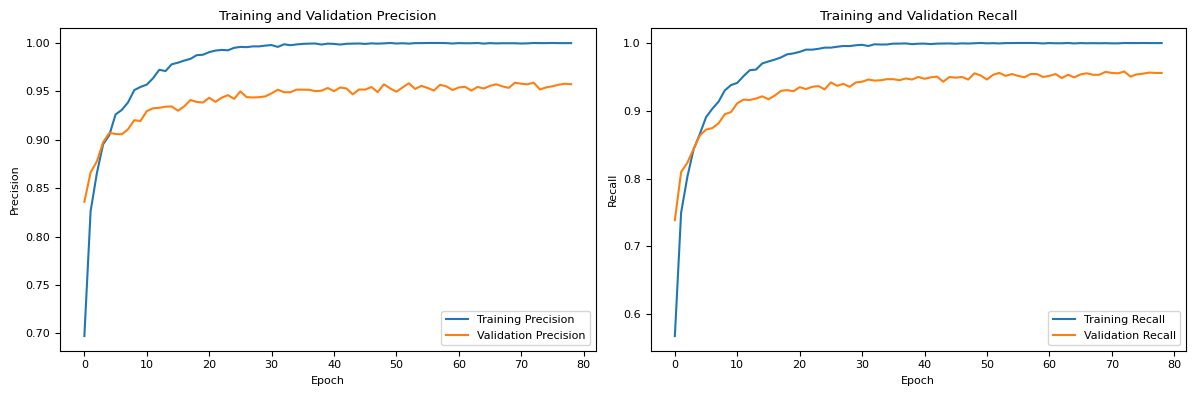

In [23]:
accuracy =  history.history[criterions[0]]  
loss = history.history[criterions[1]]
precision =  history.history[criterions[2]]  
recall =  history.history[criterions[3]] 
val_accuracy =  history.history[criterions[4] ] 
val_loss =  history.history[criterions[5]]  
val_precision =  history.history[criterions[6]]
val_recall =  history.history[criterions[7]]

    

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(precision, label='Training Precision')
plt.plot(val_precision, label='Validation Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Training and Validation Precision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, label='Training Recall')
plt.plot(val_recall, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training and Validation Recall')
plt.legend()

plt.tight_layout()
plt.show()

# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Test set prediction</p>

In [24]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

#model = load_model('opt1Channelmodel.h5')
model = tf.keras.models.load_model('/kaggle/working/opt1Channelmodel.h5', compile=False)

model.save('/kaggle/working/opt1Channelmodel.keras')
preds = model.predict(test_generator) 

pred_classes = []
for k in preds:  
    pred_classes.append(classes[np.argmax(k)])


preds = model.predict(test_generator)
pred_classes = [classes[np.argmax(p)] for p in preds]

1/1 [==============================] - 0s 48ms/step


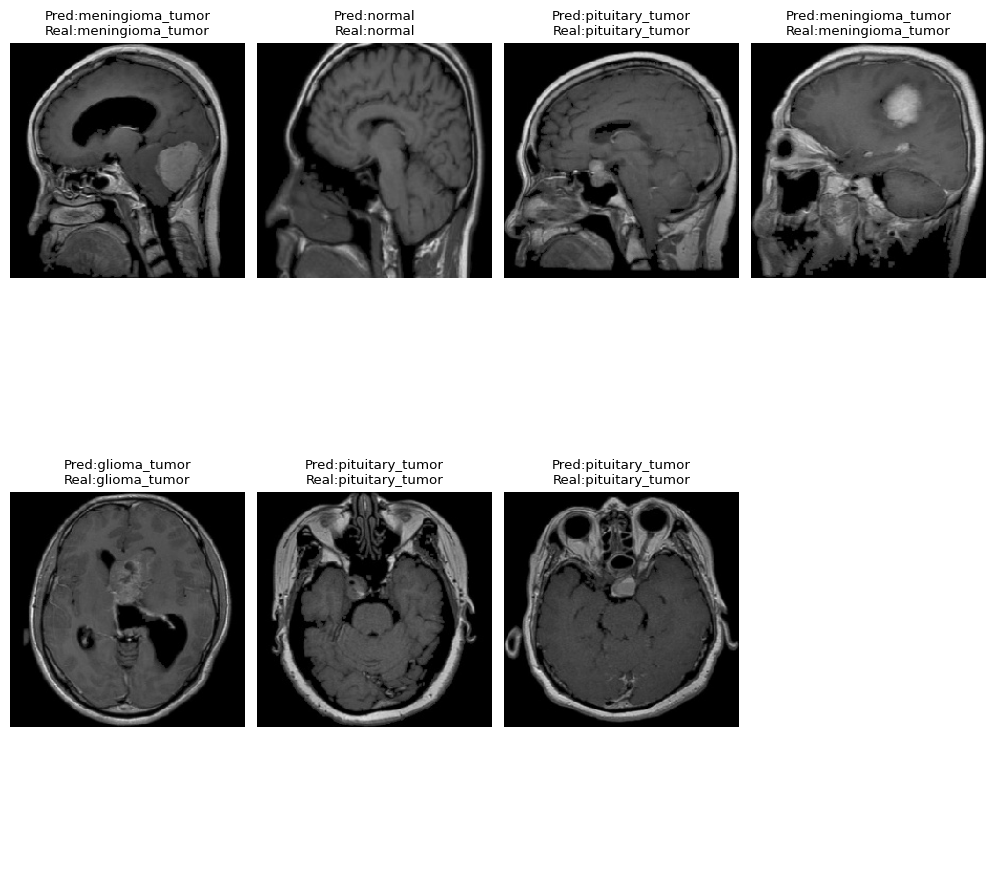

In [25]:
CLS=4
fig,ax = plt.subplots(int(len(testX)/CLS)+1,CLS, figsize=(10,10))

for i in range(int(len(testX)/CLS)+1):
    for j in range(CLS):    
        ax[i,j].axis('off')  
for i,(index,row) in enumerate(testX.iterrows()):
        r= int(i/CLS)
        c= i-CLS*r
        img = cv2.imread(row.path) 
        prediction =pred_classes[i]
        ax[r,c].imshow(img, cmap='gray') 
        ax[r,c].set_title("Pred:"+ prediction+'\n'+"Real:"+row.label ) 
plt.tight_layout()
plt.show()   


In [26]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.13.0
2.13.1
